In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [38]:
snow = pd.read_csv("../outputs/snow_stems.tsv", sep = "\t")
space = pd.read_csv("../outputs/spacy_stems.tsv", sep = "\t")
token_freq = snow.groupby("token").size().to_frame(name="freq").reset_index()
snow_freq = snow.groupby("lemma").size().to_frame(name="freq").reset_index()
space_freq = space.groupby("lemma").size().to_frame(name="freq").reset_index()

snow_unique = snow.drop_duplicates("token")

space_unique = space.drop_duplicates("token")

In [5]:
snow.describe()

,token,lemma
count,91707,91705
unique,14344,9046
top,nous,développ
freq,473,502


In [6]:
space.describe()

,token,lemma
count,91707,91707
unique,14344,11285
top,nous,son
freq,473,723


In [7]:
def plot_lemma_pareto(freq_tables, lemma_col='lemma', freq_col='freq'):
    """
    Builds a Pareto plot comparing cumulative corpus coverage across multiple tables.
    
    Args:
        freq_tables (dict): A dictionary where keys are names (e.g., 'Snow') 
                           and values are DataFrames containing frequency data.
    """
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    for name, df in freq_tables.items():
        df_sorted = df.sort_values(freq_col, ascending=False).copy()
        df_sorted['cum_counts'] = df_sorted[freq_col].cumsum()
        df_sorted['corpus_coverage'] = df_sorted['cum_counts'] / df_sorted[freq_col].sum()
        df_sorted['vocab_percent'] = np.arange(1, len(df_sorted) + 1) / len(df_sorted)
        sns.lineplot(data=df_sorted, x='vocab_percent', y='corpus_coverage', label=name, lw=2)

    # Aesthetics
    plt.axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% Coverage')
    plt.title("Pareto Curve: Cumulative Corpus Coverage by Vocabulary", fontsize=14)
    plt.xlabel("Proportion of Unique Vocabulary (Lemmas)", fontsize=12)
    plt.ylabel("Proportion of Total Text (Corpus)", fontsize=12)
    plt.xlim(0, 1.0)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

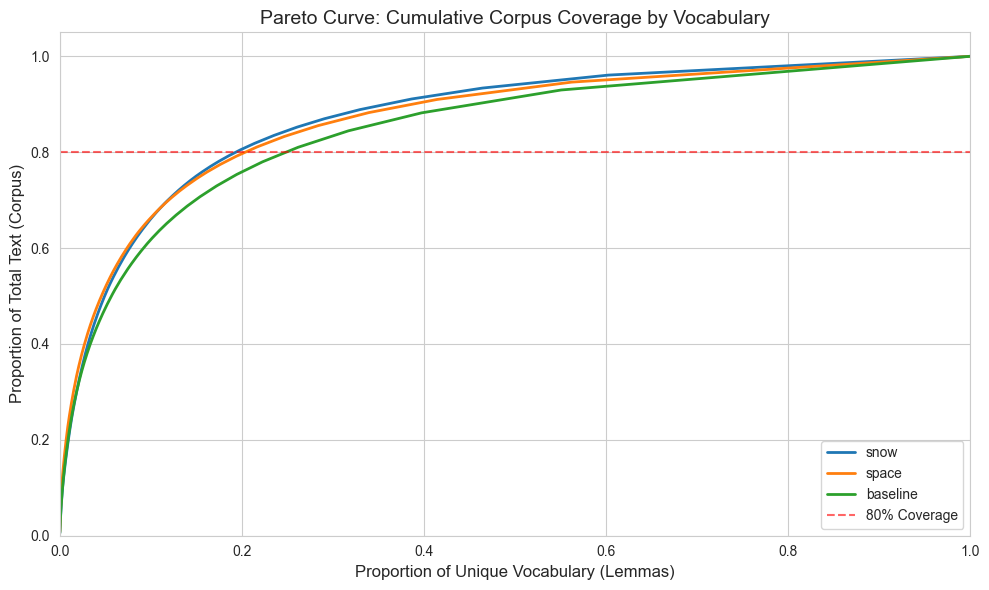

In [8]:
plot_lemma_pareto({"snow" : snow_freq, "space" : space_freq, "baseline" : token_freq })

### Recalcul de TF-IDF avec les lemmes / racines

In [46]:
"""D'abord on obtient les nouveaux tableaux documents/token"""
from lo17_dm.antidictionnaire import TFIDFProcessor
from lo17_dm.Tokenizer import CorpusTokenizer

tokenizer = CorpusTokenizer()
tokenizer.load_xml("../outputs/nostopwords_corpus.xml")
tokenizer.tokenize_corpus()
tok_table = tokenizer.get_table()

# add replace tokens with lemmas etc.
snow_table = tok_table.merge(snow_unique, on = "token", how = "inner").drop(columns="token").rename(columns={"lemma" : "token"})
spacy_table = tok_table.merge(space_unique, on = "token", how = "inner").drop(columns="token").rename(columns={"lemma" : "token"})

spacy_table


,document_id,token
0,70921,coeur
1,70921,région
2,70921,ceti
3,70921,international
4,70921,forum
...,...,...
91050,72120,dispensing
91051,72120,forum
91052,72120,congrès
91053,72120,autour


In [47]:
"""Maintenant on recalcul le TF-IDF avec ce nouveau tableau"""
processor = TFIDFProcessor(snow_table)
snow_tf = processor.compute_tf()
snow_idf = processor.compute_idf()
snow_tf_idf = processor.compute_tf_idf()
snow_tf_idf.groupby("token").mean().sort_values("tf_idf").iloc[0:50]

,document_id,tf_idf
token,,
développ,71686.203791,0.449504
présent,71928.872340,0.513728
premi,71710.005495,0.528547
leur,71771.451613,0.530647
autr,71561.012739,0.582086
permet,71747.583333,0.593183
tout,71982.411392,0.609212
direct,71307.354839,0.615023
réalis,71580.223140,0.629641


In [48]:
"""Pareil pour spacy"""
processor = TFIDFProcessor(spacy_table)
spacy_tf = processor.compute_tf()
spacy_idf = processor.compute_idf()
spacy_tf_idf = processor.compute_tf_idf()
spacy_tf_idf.groupby("token").mean().sort_values("tf_idf").iloc[0:50]

,document_id,tf_idf
token,,
son,71774.316872,0.379683
permettre,71608.419192,0.424355
premier,71693.828877,0.517603
nouveau,71847.687500,0.521720
pouvoir,71554.169014,0.524142
être,71785.407960,0.529756
tout,71995.867725,0.531135
faire,71819.724719,0.592033
autre,71562.061224,0.595325


In [49]:
"""Maintenant on recalcul le TF-IDF avec ce nouveau tableau"""
processor = TFIDFProcessor(tok_table)
control = processor.compute_tf()
control_idf = processor.compute_idf()
control_tf_idf = processor.compute_tf_idf()
control_tf_idf.groupby("token").mean().sort_values("tf_idf").iloc[0:50]

,document_id,tf_idf
token,,
cadre,71831.616822,0.700881
plusieurs,71838.010753,0.708741
autres,71475.623762,0.710439
développement,71715.781250,0.713685
autant,72092.018692,0.718968
première,71623.945455,0.720605
leur,71813.071429,0.721069
encore,71727.018868,0.722662
alors,71747.514706,0.723065


In [56]:
control_tf_idf[control_tf_idf["token"] == "leur"]["tf_idf"].mean(axis = 0)

np.float64(0.7210687871940558)